In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
from sklearn.utils.class_weight import compute_class_weight
import os

print(f"TensorFlow version: {tf.__version__}")


TensorFlow version: 2.21.0


In [2]:
# 1. Parameters

IMG_HEIGHT, IMG_WIDTH = 128, 128
BATCH_SIZE = 16  # Small batch size for stability
DATASET_PATH = "../PlantVillage"


In [5]:
# 2. Create Data Generators

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    horizontal_flip=True,
    zoom_range=0.2,
    fill_mode='nearest'
)

# Training generator
train_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',  # Important: Use 'sparse' instead of 'binary'
    subset='training',
    classes=['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy'],
    shuffle=True
)

# Validation generator
val_generator = train_datagen.flow_from_directory(
    DATASET_PATH,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='sparse',
    subset='validation',
    classes=['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy'],
    shuffle=False
)

# Get class names
class_names = list(train_generator.class_indices.keys())
print(f"\nClasses: {class_names}")
print(f"Class indices: {train_generator.class_indices}")


Found 1981 images belonging to 2 classes.
Found 494 images belonging to 2 classes.

Classes: ['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy']
Class indices: {'Pepper__bell___Bacterial_spot': 0, 'Pepper__bell___healthy': 1}


In [6]:
# 3. Calculate Class Weights (FIXED)

# Collect all labels as integers
all_labels = []
for i in range(len(train_generator)):
    _, labels = train_generator[i]
    # Convert to integers and extend
    labels = labels.astype(int)  # Important: Convert to int
    all_labels.extend(labels)

# Convert to numpy array
all_labels = np.array(all_labels)

# Get unique classes
unique_classes = np.unique(all_labels)
print(f"Unique classes found: {unique_classes}")
print(f"Class distribution: {np.bincount(all_labels)}")

# Calculate class weights
class_weights = compute_class_weight(
    'balanced',
    classes=unique_classes,  # Use unique_classes directly
    y=all_labels
)

# Create dictionary for class weights
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(f"Class weights: {class_weight_dict}")



Unique classes found: [0 1]
Class distribution: [ 798 1183]
Class weights: {0: np.float64(1.2412280701754386), 1: np.float64(0.8372781065088757)}


In [7]:
# 4. Build CNN Model

model = models.Sequential([
    # First Convolution Block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    # Second Convolution Block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    # Third Convolution Block
    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.25),
    
    # Global Pooling instead of Flatten
    layers.GlobalAveragePooling2D(),
    
    # Dense Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    
    # Output Layer (2 classes)
    layers.Dense(len(class_names), activation='softmax')
])

model.summary()


C:\Users\sai\tf_working_env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 126, 126, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 61, 61, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 28, 28, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 128)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 119,042 (465.01 KB)

 Trainable params: 118,594 (463.26 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
# 5. Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")


Model compiled successfully!


In [9]:
# 6. Callbacks

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=0.00001,
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        'best_plant_disease_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("Callbacks ready!")


Callbacks ready!


In [10]:
# 7. Train Model

EPOCHS = 20

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    verbose=1
)

print("\nTraining completed successfully!")


Epoch 1/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 744ms/step - accuracy: 0.7667 - loss: 0.4695
Epoch 1: val_accuracy improved from None to 0.59717, saving model to best_plant_disease_model.h5



Epoch 1: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 114s 864ms/step - accuracy: 0.8470 - loss: 0.3602 - val_accuracy: 0.5972 - val_loss: 0.6579 - learning_rate: 0.0010
Epoch 2/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 699ms/step - accuracy: 0.8816 - loss: 0.3073
Epoch 2: val_accuracy improved from 0.59717 to 0.65385, saving model to best_plant_disease_model.h5



Epoch 2: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 93s 751ms/step - accuracy: 0.8758 - loss: 0.3145 - val_accuracy: 0.6538 - val_loss: 0.7434 - learning_rate: 0.0010
Epoch 3/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 610ms/step - accuracy: 0.9003 - loss: 0.2541
Epoch 3: val_accuracy did not improve from 0.65385
124/124 ━━━━━━━━━━━━━━━━━━━━ 81s 654ms/step - accuracy: 0.9137 - loss: 0.2316 - val_accuracy: 0.5992 - val_loss: 1.3203 - learning_rate: 0.0010
Epoch 4/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9220 - loss: 0.2073
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 4: val_accuracy improved from 0.65385 to 0.72874, saving model to best_plant_disease_model.h5



Epoch 4: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 79s 638ms/step - accuracy: 0.9369 - loss: 0.1748 - val_accuracy: 0.7287 - val_loss: 0.8670 - learning_rate: 0.0010
Epoch 5/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.9707 - loss: 0.0905
Epoch 5: val_accuracy improved from 0.72874 to 0.94534, saving model to best_plant_disease_model.h5



Epoch 5: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 81s 653ms/step - accuracy: 0.9778 - loss: 0.0698 - val_accuracy: 0.9453 - val_loss: 0.1287 - learning_rate: 5.0000e-04
Epoch 6/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 734ms/step - accuracy: 0.9663 - loss: 0.0919
Epoch 6: val_accuracy improved from 0.94534 to 0.95951, saving model to best_plant_disease_model.h5



Epoch 6: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 103s 832ms/step - accuracy: 0.9743 - loss: 0.0761 - val_accuracy: 0.9595 - val_loss: 0.1226 - learning_rate: 5.0000e-04
Epoch 7/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.9859 - loss: 0.0488
Epoch 7: val_accuracy improved from 0.95951 to 0.97166, saving model to best_plant_disease_model.h5



Epoch 7: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 89s 715ms/step - accuracy: 0.9854 - loss: 0.0477 - val_accuracy: 0.9717 - val_loss: 0.0741 - learning_rate: 5.0000e-04
Epoch 8/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 663ms/step - accuracy: 0.9791 - loss: 0.0572
Epoch 8: val_accuracy did not improve from 0.97166
124/124 ━━━━━━━━━━━━━━━━━━━━ 88s 709ms/step - accuracy: 0.9803 - loss: 0.0604 - val_accuracy: 0.9372 - val_loss: 0.2123 - learning_rate: 5.0000e-04
Epoch 9/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9853 - loss: 0.0505
Epoch 9: val_accuracy improved from 0.97166 to 0.97571, saving model to best_plant_disease_model.h5



Epoch 9: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 81s 651ms/step - accuracy: 0.9813 - loss: 0.0583 - val_accuracy: 0.9757 - val_loss: 0.0905 - learning_rate: 5.0000e-04
Epoch 10/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 602ms/step - accuracy: 0.9874 - loss: 0.0416
Epoch 10: val_accuracy improved from 0.97571 to 0.98178, saving model to best_plant_disease_model.h5



Epoch 10: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 81s 649ms/step - accuracy: 0.9929 - loss: 0.0324 - val_accuracy: 0.9818 - val_loss: 0.0703 - learning_rate: 5.0000e-04
Epoch 11/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 612ms/step - accuracy: 0.9942 - loss: 0.0265
Epoch 11: val_accuracy improved from 0.98178 to 0.99393, saving model to best_plant_disease_model.h5



Epoch 11: finished saving model to best_plant_disease_model.h5
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 660ms/step - accuracy: 0.9934 - loss: 0.0302 - val_accuracy: 0.9939 - val_loss: 0.0452 - learning_rate: 5.0000e-04
Epoch 12/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 611ms/step - accuracy: 0.9924 - loss: 0.0261
Epoch 12: val_accuracy did not improve from 0.99393
124/124 ━━━━━━━━━━━━━━━━━━━━ 82s 657ms/step - accuracy: 0.9879 - loss: 0.0404 - val_accuracy: 0.9676 - val_loss: 0.1296 - learning_rate: 5.0000e-04
Epoch 13/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 593ms/step - accuracy: 0.9723 - loss: 0.0727
Epoch 13: val_accuracy did not improve from 0.99393
124/124 ━━━━━━━━━━━━━━━━━━━━ 79s 638ms/step - accuracy: 0.9783 - loss: 0.0657 - val_accuracy: 0.8502 - val_loss: 0.3465 - learning_rate: 5.0000e-04
Epoch 14/20
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 603ms/step - accuracy: 0.9877 - loss: 0.0350
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 14: val_accuracy did not improve from

In [11]:
# 8. Evaluate Model

# Evaluate on validation set
val_loss, val_accuracy = model.evaluate(val_generator, verbose=0)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")


Validation Loss: 0.0137
Validation Accuracy: 0.9980


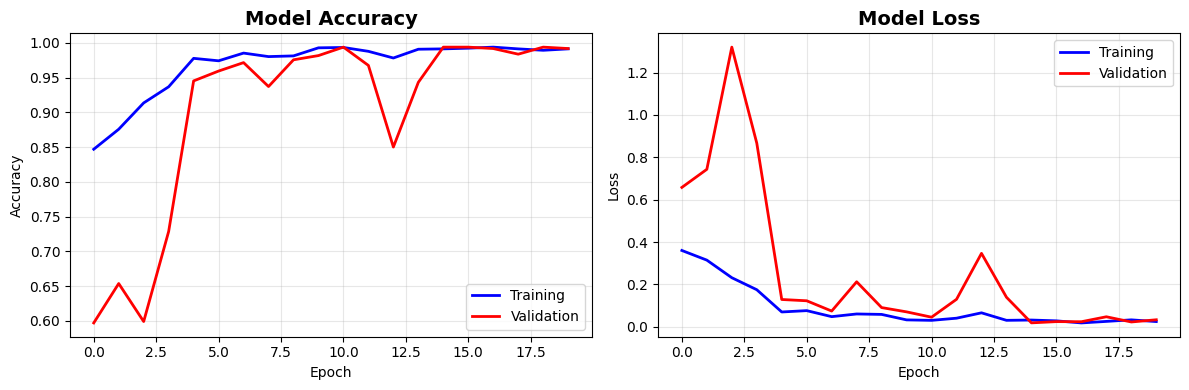

In [12]:
# 9. Plot Training History

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
ax1.plot(history.history['accuracy'], 'b-', label='Training', linewidth=2)
ax1.plot(history.history['val_accuracy'], 'r-', label='Validation', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Loss plot
ax2.plot(history.history['loss'], 'b-', label='Training', linewidth=2)
ax2.plot(history.history['val_loss'], 'r-', label='Validation', linewidth=2)
ax2.set_title('Model Loss', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [13]:
# 10. Save Model

model.save('plant_disease_model_final.h5')
print("Model saved as 'plant_disease_model_final.h5'")

# Also save in .keras format
model.save('plant_disease_model_final.keras')
print("Model saved as 'plant_disease_model_final.keras'")


Model saved as 'plant_disease_model_final.h5'
Model saved as 'plant_disease_model_final.keras'


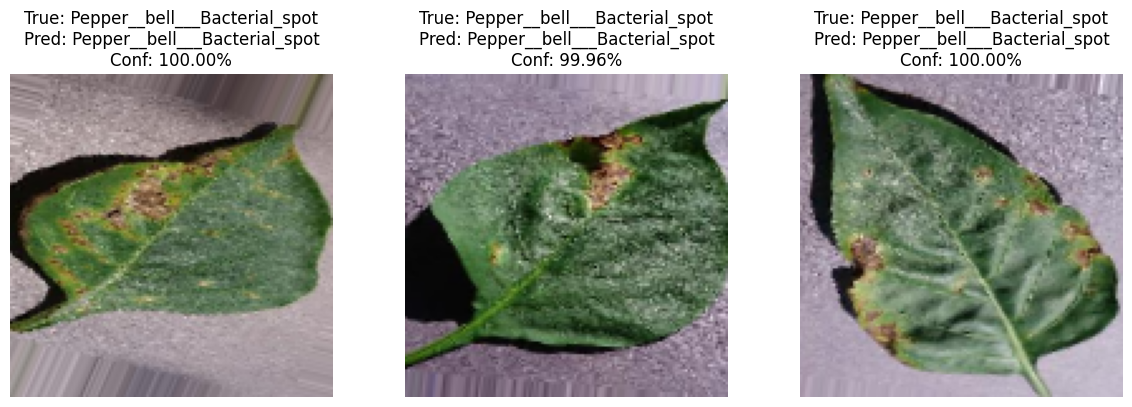

In [14]:
# 11. Test Prediction

def test_prediction(generator, model, class_names, num_samples=3):
    """Test prediction on sample images"""
    # Get a batch of images
    images, labels = next(iter(generator))
    
    plt.figure(figsize=(12, 4))
    
    for i in range(min(num_samples, len(images))):
        # Predict
        prediction = model.predict(np.expand_dims(images[i], axis=0), verbose=0)
        predicted_class = class_names[np.argmax(prediction[0])]
        confidence = np.max(prediction[0])
        true_class = class_names[int(labels[i])]
        
        # Display
        plt.subplot(1, num_samples, i+1)
        plt.imshow(images[i])
        plt.title(f"True: {true_class}\nPred: {predicted_class}\nConf: {confidence:.2%}")
        plt.axis('off')
        
        # Color code based on correctness
        if predicted_class == true_class:
            plt.gca().set_facecolor('green')
        else:
            plt.gca().set_facecolor('red')
    
    plt.tight_layout()
    plt.show()

# Test on validation generator
test_prediction(val_generator, model, class_names, num_samples=3)


In [15]:
# 12. Final Summary

print(f"\nFinal Results:")
print(f"    Model Type: Custom CNN")
print(f"    Image Size: {IMG_HEIGHT}x{IMG_WIDTH}")
print(f"    Classes: {class_names[0]}, {class_names[1]}")
print(f"    Validation Accuracy: {val_accuracy:.4f}")
print(f"    Best Accuracy: {max(history.history['val_accuracy']):.4f}")

print("----------------------------------------")

print(f"\n Saved Files:")
print(f"    best_plant_disease_model.h5")
print(f"    plant_disease_model_final.h5")
print(f"    plant_disease_model_final.keras")



Final Results:
    Model Type: Custom CNN
    Image Size: 128x128
    Classes: Pepper__bell___Bacterial_spot, Pepper__bell___healthy
    Validation Accuracy: 0.9980
    Best Accuracy: 0.9939
----------------------------------------

 Saved Files:
    best_plant_disease_model.h5
    plant_disease_model_final.h5
    plant_disease_model_final.keras
